In [86]:
import numpy as np
from queue import PriorityQueue # used to pick minimum event
import math
# Print observation table
import pandas as pd

In [79]:
#Q1 :
def simulation(lam=10, mu1=0.1, sig1=0.1,mu2=6,sig2=1,mu3=2,n1=25,n3=10, endTime=3600):
    """
    Airline preboarding system
    inputs:
        - lam: mean of the interarrival time at checkin queue
        - mu1: mean of the service times for the checkin system
        - sig1: standard deviation of the service times for the checkin system
        - mu2: mean of the commute time to the security screening system
        - sig2: standard deviation of the commute time to the security screening system
        - mu3: mean of the service times for the security system
        - sig3: standard deviation of the service times for the security system
        - n1: number of servers in the checkin system
        - n3: number of servers in the security system
        - endTime: max simulation time (minutes)

    state variables:
        - t : Current simulation time (minutes)
        - Nq : Number of people in checkin system
        - Nc : Number of people in commute to security system
        - Ns : Number of people in security system
        - Sq : Number of free servers in checkin system
        - Ss : Number of free servers in security system
        - Narr : Number of arrivals to the system
        - Ndep : Number of people who have completed security system and are ready to board
        - o : Total system occupancy (accumulated over the simulation) 
        

    outputs:
        - L : Total number of people in preboarding system averaged over time(l/T)
        - W : Total time people spend in preboarding system averaged over time(w/T)
        - S : Number of final departure per minute (Ndep/T)
    """

    # -----------------------------
    # STATE VARIABLES
    # -----------------------------

    t = 0.0       # current time
    Nq = 0.0        # number of people in checkin system
    Nc = 0.0        # number of people in commute to security system
    Ns = 0.0        # number of people in security system
    Sq = n1        # number of free servers in checkin system
    Ss = n3        # number of free servers in security system



    # -----------------------------
    # INITIAL EVENT SCHEDULING
    # -----------------------------

    firstA = np.random.exponential(1/lam)  # time of first arrival

    # PriorityQueue stores events ordered by event time
    # Each event is stored as a tuple: (event_time, event_type)
    events = PriorityQueue()
    events.put((firstA, "AC"))          # schedule first arrival
    events.put((endTime, "E"))         # schedule end-of-simulation event

    # -----------------------------
    # PERFORMANCE METRICS
    # -----------------------------
    Narr = 0.0      # number of arrivals to the system
    Ndep = 0.0      # number of people who have completed security system and are ready to board
    o = 0.0       # total system occupancy (accumulated over the simulation)
    # -----------------------------
    # MAIN EVENT LOOP (NEXT-EVENT TIME ADVANCE)
    # -----------------------------

    eventType = ''
    while(eventType != 'E'):

        if events.empty():
            print('Error: FEL is empty.')
            break

        # ------------------------------------------------
        # 1) GET NEXT EVENT (earliest event from FEL)
        # ------------------------------------------------
        nxt = events.get()            # remove earliest event
        eventTime = nxt[0]            # time of event
        eventType = nxt[1]            # type of event

        # ------------------------------------------------
        # 2) UPDATE TIME-DEPENDENT STATISTICS
        # ------------------------------------------------
        o += (Nq + Nc + Ns) * (eventTime - t)  # accumulate total system occupancy

        # Advance simulation clock
        t = eventTime

        # ------------------------------------------------
        # 3) PROCESS EVENT
        # ------------------------------------------------

        # -----------------------------
        # ARRIVAL EVENT AT CHECKIN SYSTEM
        # -----------------------------
        if eventType == "AC":
            Narr += 1
            # Customer arrives, so increment queue length
            Nq += 1
            # Schedule next arrival
            ts = np.random.exponential(1/lam)
            events.put((t + ts, "AC"))

            if (Sq > 0):
                ts = np.random.lognormal(mu1, sig1)
                events.put((t + ts, "DC"))
                Sq -= 1

        # -----------------------------
        # DEPARTURE EVENT FOR CHECKIN SYSTEM
        # -----------------------------
        elif eventType == "DC":
            Nq -= 1
            Nc += 1
            #Schedule arrival at security system
            while True:
                s2 = np.random.normal(mu2, sig2)
                if s2 > 0:
                    break
            events.put((t + s2, "AS"))

            #if there are customers waiting, start service for next customer
            if ((Nq+Sq-n1) > 0):
                ts = np.random.lognormal(mu1, sig1)
                events.put((t + ts, "DC"))
            else:
                Sq += 1

        # -----------------------------
        # ARRIVAL EVENT AT SECURITY SYSTEM
        # -----------------------------
        elif eventType == "AS":
            Nc -= 1
            Ns += 1

            #if there are servers available, start service immediately
            if (Ss > 0):
                s3 = np.random.exponential(1/mu3)
                events.put((t + s3, "DS"))
                Ss -= 1


        # -----------------------------
        # DEPARTURE EVENT FOR SECURITY SYSTEM
        # -----------------------------
        elif eventType == "DS":
            Ns -= 1
            Ndep += 1
            #if there are customers waiting, start service for next customer
            if (Ns+Ss-n3) > 0:
                s3 = np.random.exponential(1/mu3)
                events.put((t + s3, "DS"))
            else:
                Ss += 1

        # -----------------------------
        # END EVENT
        # -----------------------------
        # Nothing to do here because:
        # - busy time already updated
        # - loop exits after this iteration

    # ------------------------------------------------
    # RETURN PERFORMANCE MEASURES
    # ------------------------------------------------

    # m1 = number of completed batches
    # m2/t = proportion of time oven was busy
    return o/t, o/Narr, Ndep/t

In [74]:
L, W, S = simulation()
print('Average number of customers in system: ', L)
print('Average time spent in system: ', W)
print('Departure rate: ', S)

Average number of customers in system:  78.42297138001113
Average time spent in system:  7.792511646923546
Departure rate:  10.043055555555556


In [80]:
#Run the replications and print summary
def run_replications(nrep=20, lam=10, mu1=0.1, sig1=0.1,mu2=6,sig2=1,mu3=2,n1=25, n3=10,endTime=3600):
    """
    Run multiple independent replications of the simulation and return average performance measures.
    
    Inputs:
        nrep     : number of replications
        lam      : mean of the interarrival time at checkin queue
        mu1      : mean of the service times for the checkin system
        sig1     : standard deviation of the service times for the checkin system
        mu2      : mean of the commute time to the security screening system
        sig2     : standard deviation of the commute time to the security screening system
        mu3      : mean of the service times for the security system
        n1       : number of servers in the checkin system
        n3       : number of servers in the security system
        endTime  : max simulation time (minutes)

    Outputs:
        A dictionary containing lists of performance measures for each replication:
        - 'L': list of average number of customers in system for each replication
        - 'W': list of average time spent in system for each replication
        - 'S': list of departure rates for each replication
    """

    L = []
    W = []
    S = []

    for i in range(nrep):
        l, w, s = simulation(lam, mu1, sig1,mu2,sig2,mu3, n1, n3, endTime)
        print(f"Replication {i+1}: Average number of customers in system = {l:.4f}, Average time spent in system = {w:.4f}, Departure rate = {s:.4f}")
        L.append(l)
        W.append(w)
        S.append(s)
    return {
        'L': L,
        'W': W,
        'S': S
    }
    
#some helper function to compute CI and mean
def summary_stats(x, tcrit = 2.093): # tcrit for 95% CI with 19 df
    """
    Compute mean and 95% confidence interval for a list of values.
    Inputs:
        x : list of values
        tcrit : critical t-value for 95% CI (default is 2.093 for 19 df)
        
    Outputs:
        mean : mean of values
        sample_std : sample standard deviation of values
        ci : half-width of 95% confidence interval
        
    """
    n = len(x)
    mean = np.mean(x)
    sample_std = np.std(x, ddof=1)  # sample standard deviation
    ci = tcrit * (sample_std / math.sqrt(n))  # half-width of CI
    return {
        'mean': mean,
        'sample_std': sample_std,
        'ci_lower': mean - ci,
        'ci_upper': mean + ci
    }
    
#helper for printing summary stats

def print_system_summary(name,results):
    """Prints the mean and 95% confidence interval for a performance measure."""

    L_stats = summary_stats(results['L'])
    W_stats = summary_stats(results['W'])
    S_stats = summary_stats(results['S'])

    print(f"Summary for {name}:")
    print(f"  Average number in system: Mean = {L_stats['mean']:.3f}, 95% CI = [{L_stats['ci_lower']:.2f}, {L_stats['ci_upper']:.2f}]")
    print(f"  Average time in system: Mean = {W_stats['mean']:.2f}, 95% CI = [{W_stats['ci_lower']:.2f}, {W_stats['ci_upper']:.2f}]")
    print(f"  Departure rate: Mean = {S_stats['mean']:.4f}, 95% CI = [{S_stats['ci_lower']:.4f}, {S_stats['ci_upper']:.4f}]")
# Run replications and print summary
    return {
        "L_stats": L_stats,
        "W_stats": W_stats,
        "S_stats": S_stats
    }


In [ ]:
#Q1 - Monte Carlo Simulation and Replications
results = run_replications(
    nrep=50,
    lam=10,
    mu1=0.1,
    sig1=0.1,
    mu2=6,      
    sig2=1,
    mu3=2,
    n1=25, 
    n3=10,
    endTime=3600 #aday(min)
)
#mu=0.5-> 2per minute is equal to mean of 0.5 minutes per customer
baseline_summary = print_system_summary("Baseline", results)

Replication 1: Average number of customers in system = 78.0510, Average time spent in system = 7.7895, Departure rate = 9.9967
Replication 2: Average number of customers in system = 77.7092, Average time spent in system = 7.7923, Departure rate = 9.9564
Replication 3: Average number of customers in system = 77.6851, Average time spent in system = 7.7930, Departure rate = 9.9458
Replication 4: Average number of customers in system = 77.7394, Average time spent in system = 7.7539, Departure rate = 10.0022
Replication 5: Average number of customers in system = 76.8600, Average time spent in system = 7.7452, Departure rate = 9.8997
Replication 6: Average number of customers in system = 77.4048, Average time spent in system = 7.7698, Departure rate = 9.9411
Replication 7: Average number of customers in system = 77.1017, Average time spent in system = 7.7076, Departure rate = 9.9831
Replication 8: Average number of customers in system = 76.8182, Average time spent in system = 7.7006, Departu


Running for lambda = 5
Replication 1: Average number of customers in system = 38.0982, Average time spent in system = 7.6936, Departure rate = 4.9417
Replication 2: Average number of customers in system = 39.3031, Average time spent in system = 7.7884, Departure rate = 5.0356
Replication 3: Average number of customers in system = 38.6871, Average time spent in system = 7.7911, Departure rate = 4.9575
Replication 4: Average number of customers in system = 38.9518, Average time spent in system = 7.7834, Departure rate = 4.9911
Replication 5: Average number of customers in system = 38.4328, Average time spent in system = 7.7140, Departure rate = 4.9700
Replication 6: Average number of customers in system = 39.0148, Average time spent in system = 7.7753, Departure rate = 5.0072
Replication 7: Average number of customers in system = 38.2326, Average time spent in system = 7.6871, Departure rate = 4.9622
Replication 8: Average number of customers in system = 38.9233, Average time spent in s

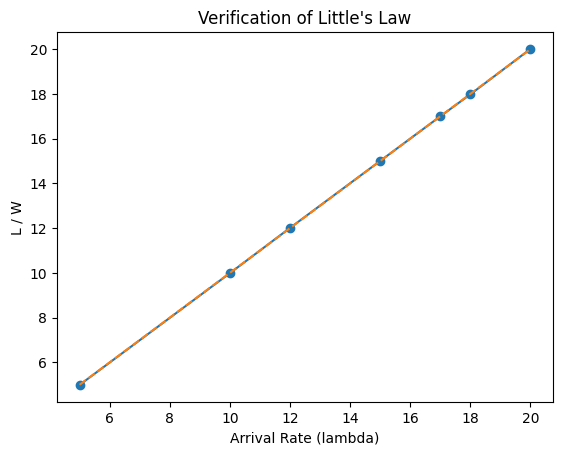


Observation Table:
   Lambda  Average L  Average W  Average S     L/W
0       5     38.682      7.747      4.982   4.993
1      10     77.629      7.772      9.967   9.988
2      12     93.423      7.779     11.983  12.010
3      15    117.014      7.799     14.972  15.004
4      17    134.320      7.902     16.960  16.998
5      18    145.005      8.064     17.941  17.981
6      20    364.541     18.217     19.884  20.011


In [91]:
#Task 1
lambdas = [5, 10, 12, 15, 17, 18, 20]
#lambdas = [20,25, 30, 35] #exploded

L_means = []
W_means = []
S_means = []
ratio = []

for lam in lambdas:
    print(f"\nRunning for lambda = {lam}")
    
    results = run_replications(
        nrep=30,   # reduce a bit for speed
        lam=lam,
        mu1=0.1,
        sig1=0.1,
        mu2=6,
        sig2=1,
        mu3=2,
        n1=25,
        n3=10,
        endTime=3600   # increase time for stability
    )
    
    summary = print_system_summary(f"lambda = {lam}", results)
    
    L_avg = summary["L_stats"]["mean"]
    W_avg = summary["W_stats"]["mean"]
    S_avg = summary["S_stats"]["mean"]
    
    L_means.append(L_avg)
    W_means.append(W_avg)
    S_means.append(S_avg)
    ratio.append(L_avg / W_avg)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(lambdas, ratio, marker='o')
plt.plot(lambdas, lambdas, linestyle='--')  # reference line y = lambda
plt.xlabel("Arrival Rate (lambda)")
plt.ylabel("L / W")
plt.title("Verification of Little's Law")
plt.show()

# Print observation table
import pandas as pd
obs_table = pd.DataFrame({
    "Lambda": lambdas,
    "Average L": L_means,
    "Average W": W_means,
    "Average S": S_means,
    "L/W": ratio
})

print("\nObservation Table:")
print(obs_table.round(3))
obs_table["Status"] = ["Stable" if S >= lam else "Unstable" for S, lam in zip(S_means, lambdas)]


In [92]:
#Task 2
best_cost = float('inf')  # start with a very high cost
best_n3 = None             # store the n3 corresponding to best cost
costs = []                 # optional: store cost for all n3 for plotting
stable_n3 = []             # optional: store stable n3

#loop n3 and compute cost for each n3
for n3 in range(1, 21):
    results = run_replications(nrep=30, lam=10, mu1=0.1, sig1=0.1,
                               mu2=6, sig2=1, mu3=2, n3=n3, endTime=5000)
    
    L_avg = summary_stats(results['L'])['mean']
    S_avg = summary_stats(results['S'])['mean']
    
    # Check stability
    if L_avg > 1000:  # threshold to mark unstable system
        print(f"n3={n3} is unstable")
        cost = float('inf')
    else:
        print(f"n3={n3} is stable: L={L_avg:.2f}, S={S_avg:.2f}")
        stable_n3.append(n3)
        cost = L_avg - S_avg + 10*n3  # cost function
    
    costs.append(cost)
    
    # Update best_n3 if this cost is lower
    if cost < best_cost:
        best_cost = cost
        best_n3 = n3

# Print the best n3 and its cost
print(f"\nOptimal n3 = {best_n3} with minimum cost = {best_cost:.2f}")



import pandas as pd

# After your existing loop
# Compute W for table
W_means = [summary_stats(run_replications(nrep=1, lam=10, mu1=0.1, sig1=0.1,
                                          mu2=6, sig2=1, mu3=2, n3=n3, endTime=5000)['W'])['mean']
           for n3 in range(1, 21)]

# Status: Stable if L < 1000 else Unstable
status = ["Stable" if cost < float('inf') else "Unstable" for cost in costs]

# Create observation table
task2_table = pd.DataFrame({
    "n3": range(1, 21),
    "Average L": [summary_stats(run_replications(nrep=1, lam=10, mu1=0.1, sig1=0.1,
                                                 mu2=6, sig2=1, mu3=2, n3=n3, endTime=5000)['L'])['mean']
                  for n3 in range(1, 21)],
    "Average W": W_means,
    "Departure Rate S": [summary_stats(run_replications(nrep=1, lam=10, mu1=0.1, sig1=0.1,
                                                        mu2=6, sig2=1, mu3=2, n3=n3, endTime=5000)['S'])['mean']
                         for n3 in range(1, 21)],
    "Cost": costs,
    "Status": status
})

print("\nTask 2 Observation Table:")
print(task2_table.round(2))

Replication 1: Average number of customers in system = 19900.2505, Average time spent in system = 1993.2941, Departure rate = 1.9996
Replication 2: Average number of customers in system = 20014.0114, Average time spent in system = 1993.0304, Departure rate = 2.0014
Replication 3: Average number of customers in system = 20059.6155, Average time spent in system = 2007.2462, Departure rate = 1.9402
Replication 4: Average number of customers in system = 20029.4132, Average time spent in system = 2000.5407, Departure rate = 1.9842
Replication 5: Average number of customers in system = 19963.2003, Average time spent in system = 1995.0432, Departure rate = 2.0152
Replication 6: Average number of customers in system = 20049.9915, Average time spent in system = 2002.3560, Departure rate = 2.0118
Replication 7: Average number of customers in system = 19997.0042, Average time spent in system = 2000.4606, Departure rate = 2.0114
Replication 8: Average number of customers in system = 19999.7166, Av

c:\Users\janha\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\janha\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Replication 1: Average number of customers in system = 15196.6029, Average time spent in system = 1512.2202, Departure rate = 3.9936
Replication 1: Average number of customers in system = 10091.4736, Average time spent in system = 1011.3724, Departure rate = 5.9962
Replication 1: Average number of customers in system = 4774.8157, Average time spent in system = 477.5198, Departure rate = 8.0584
Replication 1: Average number of customers in system = 197.2894, Average time spent in system = 19.6896, Departure rate = 9.9594
Replication 1: Average number of customers in system = 80.5582, Average time spent in system = 8.0882, Departure rate = 9.9452
Replication 1: Average number of customers in system = 79.1307, Average time spent in system = 7.8877, Departure rate = 10.0166
Replication 1: Average number of customers in system = 78.1440, Average time spent in system = 7.7831, Departure rate = 10.0230
Replication 1: Average number of customers in system = 77.5683, Average time spent in syste